### <center> Simulating Dynamical Systems </center>

#### What is a Dynamical System?

Dynamical Systems are mathematical systems that evolve in time. They are characterized by an update rule that describes how the system evolves from one time point to the next. First, let's define a discrete time dynamical system

$$
t \in 0,1,\cdots
$$
$$
X_{t+1} = f(X_{t}).
$$

So the state of a system $X_{t}$ is updated at specific time intervals(e.g. yearly, daily, hourly) using a function $f$. 

#### Example of a Discrete Dynamical System

The first dynamical system we will look at is inspired by biology. Consider a bacteria population in a medium with infinite resources. Let $X_t$ be the population of bacteria in the medium at time $t$. If the bacteria double every hour, we can update $X_{t}$ hourly and write 

$$
X_{t+1} = 2 X_t
$$

where $t \in \text{hour 0}, \text{hour 1}, \dots$. 

Now we will use python to simulate this dynamical system and predict bacteria populations in the future. Before starting, note that we will require one more component to fully specify this system, the initial condition. If we don't know the population of the bacteria at time 0 we cannot calculate the population at time 1 and therefore we can't predict the population at time 2 and so on. 

Let's set the initial population of bacteria to 1, so $X_{0} = 1$. 

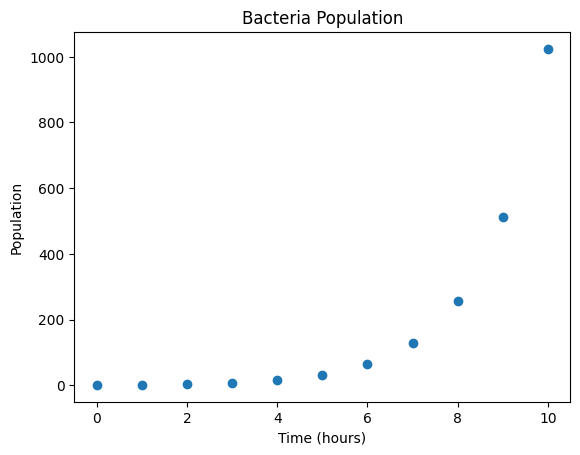

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ts = np.arange(0,10 + 1,1) #We will compute the bacteria population over a ten hour period

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

for t_index in range(1,len(ts)): 
    xs[t_index] = 2 * xs[t_index - 1]

plt.title('Bacteria Population')
plt.scatter(ts,xs)
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.show()

### Exercise 1

---

This model is good for the growth phase of bacteria, but it assumes the amount of food available to the bacteria is unlimited. In practice the bacteria population will not grow forever and will plateau as the amount of food in the environment declines. We can adjust our model to reflect this, 

$$
X_{t+1} = X_{t} + X_{t}\left(1 - \frac{X_{t}}{N}\right)
$$

where the term $\left(1 - \frac{X_{t}}{N}\right)$ will damp the growth of $X_t$ as it gets close to $N$. The parameter $N$ represents the "carrying capacity" of the environment, e.g. the number of bacteria the environment can support. Let's set $N = 100$ and simulate this new system. 

This simulation should "look like" the original model near the beginning but begin to plateau near the carrying capacity as time goes on. 

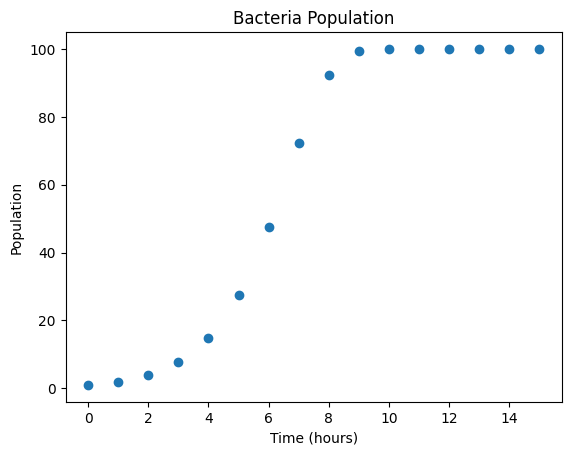

In [2]:
ts = np.arange(0,15 + 1,1) #We will compute the bacteria population over a ten hour period

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

N = 100

for t_index in range(1,len(ts)): 
    xs[t_index] = xs[t_index - 1] + xs[t_index - 1] * (1 - xs[t_index - 1]/N)

plt.title('Bacteria Population')
plt.scatter(ts,xs)
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.show()



Observing the graph we see that we only know the number of bacteria each hour, but in reality bacteria reproduce continuously. This raises the question, "Can we create a dynamical system in continuous time with the same properties as our discrete time dynamics?"

First lets examine 
$$
X_{t+1} = 2X_{t} 
$$
and rewrite this system as

$$
X_{t+1} = X_{t} + X_{t}.
$$

We will further introduce a variable $\Delta t$ which is the length of time between successive time points. In our case $\Delta t = \text{1 hour}$. 
Rewriting yields

$$
X_{t+1} - X_{t} = X_{t} \cdot \Delta t
$$

and dividing through by $\Delta t$ yields

$$
\frac{X_{t+1} - X_{t}}{\Delta t} = X_{t}.
$$ 

Now we we substitute $X_{t+1} = X_{t+\Delta t}$

$$
\frac{X_{t+
\Delta t} - X_{t}}{\Delta t} = X_t. 
$$
Since $\Delta_t = \text{1 hour}$ we haven't changed the equations at all, only divided by $1$ and made a change of notation. Let's consider what would happen if instead of doubling every hour the bacteria doubled every $30$ minutes. We can simply substitute $\Delta t = 0.5$ and the equations are unchanged. The continuous time system arises from considering what would happen if we continue to shrink the doubling interval by taking a mathematical limit 

$$
\lim\limits_{\Delta t \rightarrow 0} \frac{X_{t+
\Delta t} - X_{t}}{\Delta t} = \frac{dX}{dt}=X(t). 
$$

Therefore the continuous time dynamical system $\frac{dX(t)}{dt} = X(t)$ can be viewed as a limit of our original discrete system as the distance between time points goes to zero. We can solve this system to find an expression for $X(t)$. 

Starting with
$$
\frac{dX(t)}{dt} = X(t)
$$
we can rearrange and integrate both sides with respect to $t$
$$
\frac{dX}{X(t)} = dt
$$

and 

$$
\begin{align*}
\int \frac{dX(t)}{X(t)} = \int dt. 
\end{align*}
$$

Solving the integrals yields

$$
\begin{align*}
\ln(X(t)) &= t + C \\
X(t) &= e^{t + C} = e^{t}e^{C} \\
X(t) = De^{t}
\end{align*}
$$

where $D$ is an unknown constant which we can identify through the initial condition
$$
\begin{align*}
X(0) &= De^{0} \\
1 &= D.
\end{align*}
$$

So we are left with the $X(t) = e^{x}$. Let's now plot this function alongside our discrete time dynamical system above. 




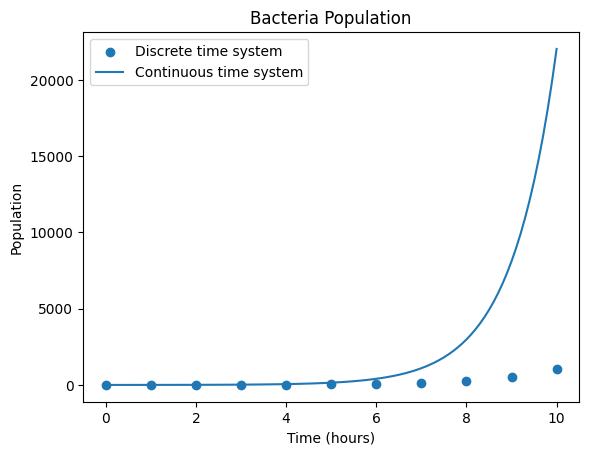

In [3]:
ts = np.arange(0,10 + 1,1) #We will compute the bacteria population over a ten hour period
ts_cont = np.arange(0,10 + 0.1,0.1)

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

for t_index in range(1,len(ts)): 
    xs[t_index] = 2 * xs[t_index - 1]

plt.title('Bacteria Population')
plt.scatter(ts,xs,label = 'Discrete time system')
plt.plot(ts_cont,np.exp(ts_cont),label = 'Continuous time system')
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.legend()
plt.show()

It appears the continuous time dynamical system grows far more quickly than the discrete time system. Why is this? 

We will introduce a parameter $r$ that we call the growth rate. This parameter controls how quickly the population of bacteria grows and can be adjusted for different species of bacteria. If we assume as in our discrete time system that the bacteria population doubles every hour we can find value for $r$ such that $X(t) = X_t$ at each hour. 

Lets consider $X_{t}$ at hour 1. Since our population doubles each hour $X_{1} = 2$ as we started from a single bacteria. Let 

$$
\begin{align*}
X(1) &= X_{1} \\
e^{r} &= 2 \\
\ln(e^{r}) &= \ln(2) \\
r &= \ln(2). 
\end{align*}
$$

So we have derived our growth rate $r = \ln(2)$. Let's plot the two equations again.

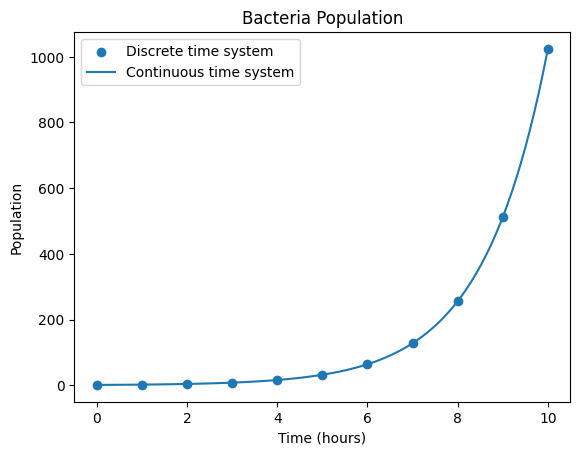

In [4]:
ts = np.arange(0,10 + 1,1) #We will compute the bacteria population over a ten hour period
ts_cont = np.arange(0,10 + 0.1,0.1)

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

r = np.log(2)

for t_index in range(1,len(ts)): 
    xs[t_index] = 2 * xs[t_index - 1]

cont_time_system = np.exp(r * ts_cont)

plt.title('Bacteria Population')
plt.scatter(ts,xs,label = 'Discrete time system')
plt.plot(ts_cont,cont_time_system,label = 'Continuous time system')
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.legend()
plt.show()

We could follow a similar process to derive a continuous time logistic growth equation. However, the expression for $X(t)$ is quite a bit more complicated. We will omit the steps here but the solution to the continuous time logistic growth equation is 

$$
X(t) = \frac{N}{1 + \left(\frac{N - X_0}{X_0}\right) e^{-rt}}
$$

Where $X_{0} = X(0) = 1$.

#### Solving Continuous Time Dynamical Systems Numerically

---

In general, continuous time dynamical systems look like 

$$
\begin{align*}
\frac{dX}{dt} &= f(X(t),t) \\
X(0) &= X_{0}
\end{align*}
$$
an update rule given by a differential equation and an initial condition. One would hope we could solve all differential equations algebraically, however this is impossible in general. There are many interesting dynamical systems that don't have an algebraic solution, so how do we solve them? 

We turn to simulation, and derive a discrete time dynamical system that is "close" to our continuous time system.
Then we use the approximation 

$$
\begin{aligned}
\frac{dX}{dt} \approx \frac{X(t+\Delta t) - X(t)}{\Delta t}
\end{aligned}
$$

where we have substituted the concrete time step $\Delta t$ for the infinitesimal time step $dt$. The value of $\Delta t$ controls the error of the approximation. Our finite difference derivative then becomes

$$
\begin{aligned}
\frac{X(t+\Delta t) - X(t)}{\Delta t} = f(X(t),t). 
\end{aligned}
$$. 

We can solve this expression for $X(t + \Delta t)$ to obtain an update formula 

$$
\begin{aligned}
X(t + \Delta t) = X(t) + \Delta t \cdot f(X(t),t) 
\end{aligned}
$$. 

This formula gives us a recursion relation by which we can obtain an approximate solution to $X(t)$ on a grid of time points $[0,\Delta t, 2\Delta t, \dots]$ given a starting point $X(0) = X_0$.

Let's code up this formula to approximation an unsolvable dynamical system 

$$
\begin{align*}
\frac{dX}{dt} &= t - X - X^3 \\
X(0) &= 0. \\
\end{align*}
$$



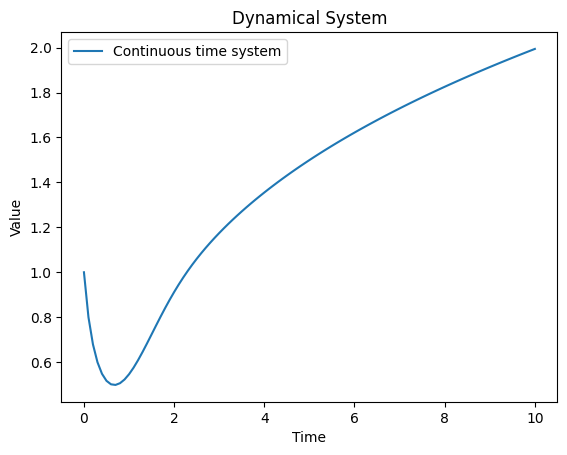

In [5]:
delta_t = 0.1
ts_cont = np.arange(0,10 + delta_t,delta_t)

xs = np.zeros(len(ts_cont))
xs[0] = 1 #Set the initial condition

def f(X,t): 
    return t - X - X**3

for t_index in range(1,len(ts_cont)): 
    x_prev = xs[t_index - 1]
    xs[t_index] = x_prev + delta_t * f(x_prev,ts_cont[t_index -1])

plt.title('Dynamical System')
plt.plot(ts_cont,xs,label = 'Continuous time system')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

### Multi-Dimensional Dynamical Systems

Dynamical systems don't have to be limited to only a single variable $X(t)$. We can utilize any number of variables and our definitions above easily extend to this regime. 

To illustrate, we will consider a two dimensional continuous time dynamical system, the Lotka-Volterra equations. These equations are used to describe a biological system in which two species interact, one as a predator and one as prey. The equations are as follows, 

$$
\begin{align*}
\frac{dx}{dt} &= \alpha x - \beta xy \\
\frac{dy}{dt} &= -\gamma y + \delta xy
\end{align*}
$$

where $x$ is the density of prey and $y$ is the density of predators. The parameter $\alpha$ describes the growth rate of prey, and the parameter $\beta$ the effect of the presence of predators on the prey death rate. The parameter $\gamma$ describes the predators death rate, and the parameter $\delta$ describes the effect of the presence of prey on the predators growth rate. 

To solve this equation numerically, we follow the same procedure as for our one dimensional dynamical systems but treating $X(t)$ as the vector $X(t) = [x(t),y(t)]^{T}$ instead of a scalar. 



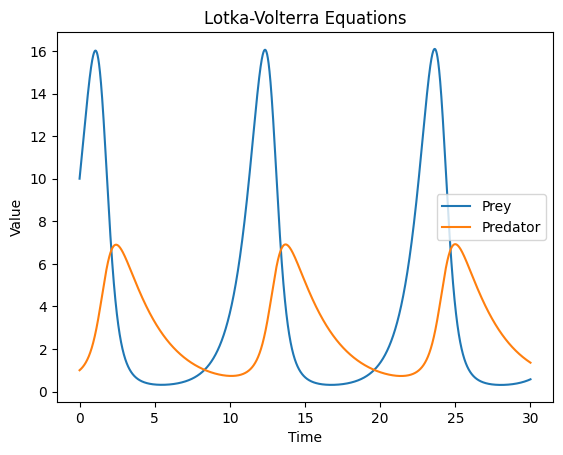

In [6]:
par = np.array([1.1,0.4,0.4,0.1]) #alpha,beta,gamma,delta

delta_t = 0.001
ts_cont = np.arange(0,30 + delta_t,delta_t)

xs = np.zeros((len(ts_cont),2))
xs[0,:] = np.array([10.,1.]) #Set the initial condition

def f(X,params):
    x,y = X
    alpha,beta,gamma,delta = params 
    dx = alpha * x - beta * x * y
    dy = - gamma * y + delta * x * y
    return np.array([dx,dy])

for t_index in range(1,len(ts_cont)): 
    x_prev = xs[t_index - 1]
    xs[t_index] = x_prev + delta_t * f(x_prev,par)

plt.title('Lotka-Volterra Equations')
plt.plot(ts_cont,xs,label = ['Prey','Predator'])
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

### Exercise 2

---

(a) What would be the solutions of $x(t)$ and $y(t)$ if the $xy$ terms were omitted? 
(b) What happens if you set $\Delta t$ to $0.1$ or $1.0$? How does the solution approximation change? 
(c) Plot $x(t)$ against $y(t)$, what can we infer from the resultant plot? 

### SIS Model 

This model will be our first foray into epidemiological models. This model has two variables, which we call $S$ and $I$ for susceptible and infected respectively. The susceptible compartment is the proportion of a given population which can be infected with disease and the infected is the proportion of the population actively infected. The equations are as follows 

$$
\begin{align*}
\frac{dS}{dt} &= -\beta S I + \gamma I \\
\frac{dI}{dt} &= \beta S I - \gamma I
\end{align*}
$$

where $\beta$ is the disease transmission rate and $\gamma$ is the recovery rate. 

It's important to note the SIS model assumes that people who recover from disease immediately reenter the susceptible compartment, i.e. there is no immunity period. While most diseases don't satisfy this assumption, some sexually transmitted diseases do. 

### Exercise 3
---
(a) Simulate the SIS model using $\beta = 0.3$ and $\gamma = 0.1$. 

(b) Evaluate the effect of changing $\delta t$ on the solution. In particular, choose different values of $\delta t$ and graph the resultant $I(t)$ curve for each $\delta t$ on the same plot. 

(c) Evaluate the effect of changing $\beta$ and $\gamma$. Plot the results of keeping $\gamma$ fixed and changing $\beta$ and the results of keeping $\beta$ fixed and changing $\gamma$. What happens if $\gamma > \beta$?

### Extensions of the SIS Model

The SIS model is a useful tool for epidemiological modeling but it has limitations. In particular, the SIS model does not describe the impact of immunity. In many dieases such as influenza those who contract the disease cannot be infected again within the same season and effectively exit the disease dynamics. To describe immunity in a compartmental framework we introduce an additional compartment called R(recovered or removed). 

$$
\begin{align*}
\frac{dS}{dt} &= -\beta S I \\
\frac{dI}{dt} & = \beta S I  - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{align*}
$$

People who contract the disease and recover do not reenter the disease dynamics, hence the label "removed". 

### Exercise 4

---

(a) Simulate the SIR model using the parameter values $\beta = 0.3$,$\gamma = 0.1$, and the initial condition $S = 500$, $I = 5$, and $R = 0$. 

## Graphical Modeling

The SIR framework can really be extended to any number of compartments, and a variety of models have been proposed including SEIR (Exposed) for COVID and SIRH (Hospitalized) which incorporates a hospitalization compartment. A useful tool to visualize these models is to describe them as a directed graph. For example the SIR model can written as 

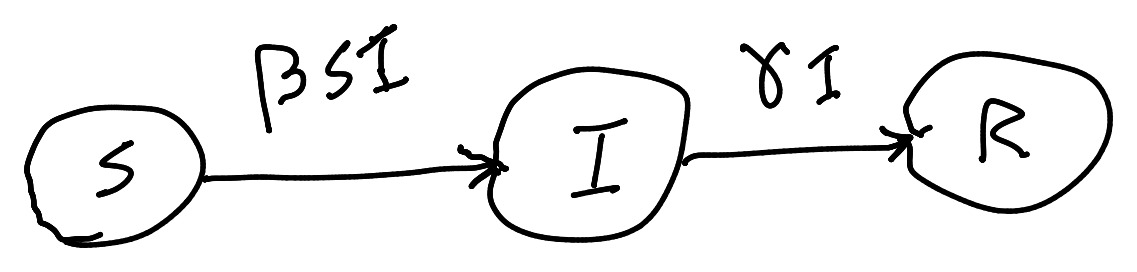

where we think of people flowing between the compartments with rates given by $\beta S I$ and $\gamma I$. 

We can write an SIRH model as 

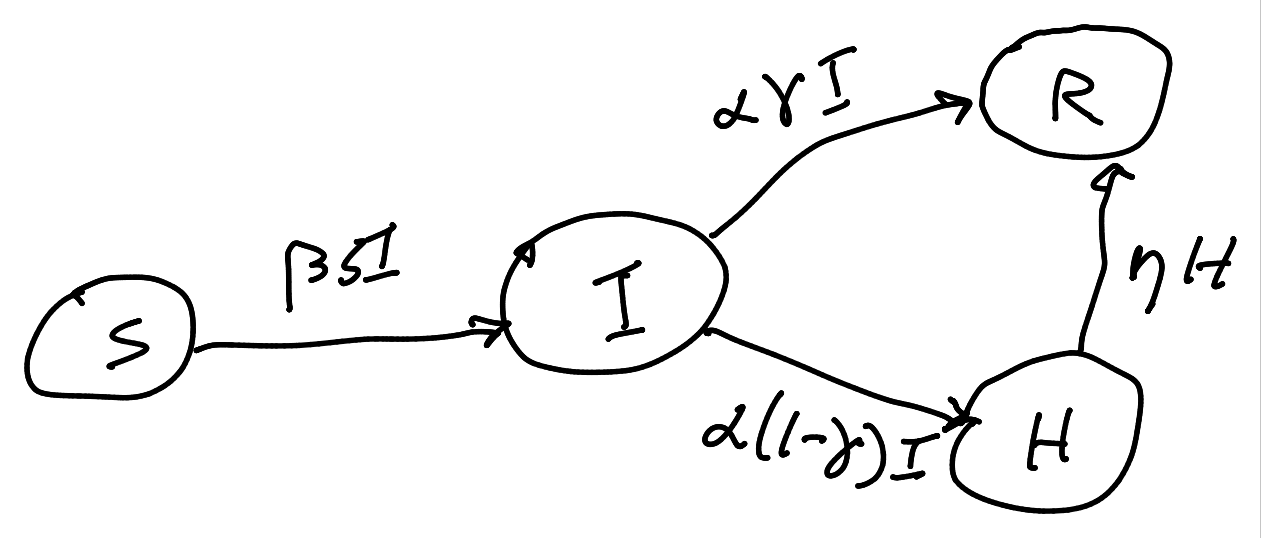

where $\beta,\gamma,\alpha,\gamma$ are rate parameters. 

### Exercise 5

---

(a) Write an SIRS model as both a graph and a differential equation. That is, a model where people can reenter the susceptible pool from the recovered compartment. 

(b) Simulate the SIRS model, how do the dynamics change when compared to the SIR model? 

(c) Write the graphical SIRH model as a system of differential equations. 

### Parameter Inference and the Loss Function

In our simulation examples we knew the initial condition and parameters of the system ($\beta$,$\gamma$) and generated a solution $X(t) = [S(t),I(t),R(t)]^T$. In practice we often have a noisy estimate of the solution to the system, and we want to figure out what the parameters are. As a motivational example consider the following fictional example.

We have a dataset representing recorded influenza infections in a town of $500$ over the past year's flu season (october-may). First, we will load and plot this dataset to determine if our SIR model will be a good fit. 

In [7]:
import pandas as pd

data = pd.read_csv('../fictious_data.csv')

print(data.shape) #(rows,columns)

data.head() ## Prints the first few rows of the dataframe

(212, 2)


,date,count
0,2025-10-01,3
1,2025-10-02,7
2,2025-10-03,3
3,2025-10-04,4
4,2025-10-05,10


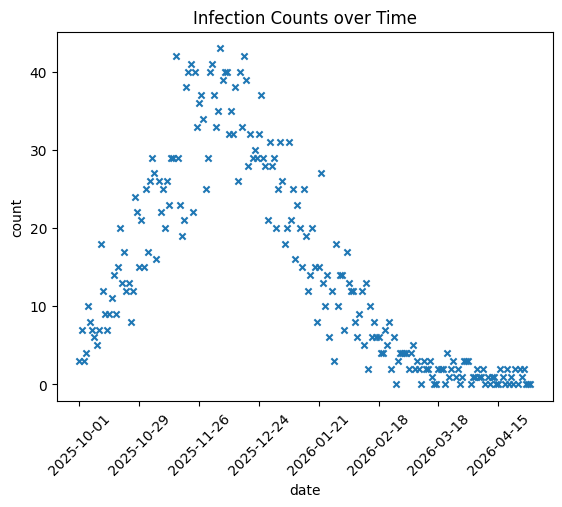

In [8]:
import matplotlib.ticker as ticker

ax = data.plot(x='date', y='count', kind='scatter',rot = 45,marker = 'x')

ax.set_title('Infection Counts over Time')
ax.xaxis.set_major_locator(ticker.MultipleLocator(28))

So our data appears to well approximate our SIR infection curve, and therefore we can try to learn the transmission and recovery rates. For this example, let's assume we know the initial condition $X(0) = [495,5,0]$ but in general it is also possible to learn this from data!

### The Loss Function

Let's think about how we could try to uncover the data generating parameters $\beta$ and $\gamma$. 

We have noisy data about the infection curve $I(t)$ and we need some way to relate our data to our model. To do so, we can utilize what's called a loss function. The loss function is a scalar function that takes in our proposed parameter values and outputs a single value representing the distance between the data and the proposed solution. Mathematically we can write the loss function as 

$$
\begin{align*}
\mathcal{L}(\beta,\gamma) = \sum\limits_{n=1}^{N}(x_{n} - I(t_n;\beta,\gamma))^2
\end{align*}
$$
where $\{x\}_{n=1}^{N}$ represents the data($N$ days of data) and $I(t_n;\beta,\gamma)$ the I compartment solution with the proposed parameter values. 

So our inference process proceeds by proposing a value of the parameters, evaluating the loss function at that value, then making a new guess until the value of the loss function is sufficiently small. Our loss function should be minimized when the distance between the data and the $I$ compartment is as small as possible.

We now implement the loss function in Python. First, lets wrap our Euler solver up in a function.

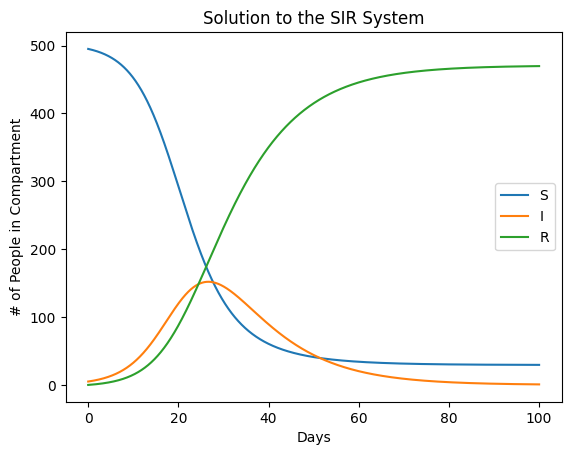

In [9]:
def sir_rhs(X,params):
    S,I,R = X
    N = S + I + R
    beta,gamma = params 
    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I
    return np.array([dS,dI,dR])


def model(rhs,x0,ts,par):
    delta_t = ts[1]-ts[0] 
    xs = np.zeros((len(ts),len(x0)))
    xs[0,:] = x0 

    for t_index in range(1,len(ts)): 
        x_prev = xs[t_index - 1]
        xs[t_index] = x_prev + delta_t * rhs(x_prev,par)

    return xs

x0 = np.array([495.,5.,0.])
delta_t = 0.01
ts = np.arange(0,100 + delta_t,delta_t)
par = (0.3,0.1) #beta,gamma

sol = model(sir_rhs,x0,ts,par)

plt.title("Solution to the SIR System")
plt.plot(ts,sol,label = ['S','I','R'])
plt.ylabel('# of People in Compartment')
plt.xlabel('Days')
plt.legend()
plt.show()

Now we implement the loss function, the notation `::int(1/delta_t)` is used to extract every `1/delta_t`th element. Since `delta_t` is 0.1 this extracts every 10th element, i.e. the value of the model on each day. 

In [10]:
def loss(par_prop,data):
    x0 = np.array([495.,5.,0.])
    delta_t = 0.01
    ts = np.arange(0,len(data),delta_t)
    sol_prop = model(sir_rhs,x0,ts,par_prop)
    return np.sum((data - sol_prop[::int(1/delta_t),1])**2) 

loss((0.3,0.1),data['count'].to_numpy())

np.float64(355524.76875097025)

Great! So we can evaluate our loss function for different values of the parameters. Now we want to find the values of the parameters which minimize the loss function. To start with we can plot our loss function to visualize it. 

In [11]:
spacing = 0.01
param_range = np.arange(0, 0.5 + spacing, spacing)

B, G = np.meshgrid(param_range, param_range)
loss_vals = np.zeros(B.shape)

numpy_data = data['count'].to_numpy()

for i in range(len(param_range)): 
    for j in range(len(param_range)): 
        loss_vals[i, j] = loss((B[i, j], G[i, j]), numpy_data)

flat_index = np.argmin(loss_vals)
row, col = np.unravel_index(flat_index, loss_vals.shape)
best_beta = B[row, col]
best_gamma = G[row, col]
min_loss = loss_vals[row, col]

print(f"Minimum occurs at: β={best_beta:.4f}, γ={best_gamma:.4f} with value {min_loss:.4f}")



Minimum occurs at: β=0.1500, γ=0.1000 with value 3403.3117


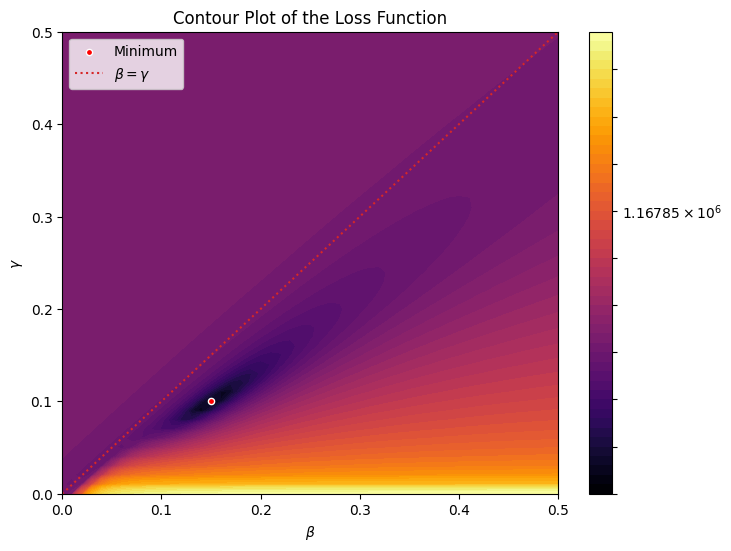

In [12]:

plt.figure(figsize=(8, 6))
from matplotlib.colors import LogNorm

plt.contourf(B, G, loss_vals, levels=np.logspace(np.log10(loss_vals.min()), 
                                               np.log10(loss_vals.max()), 50), 
             norm=LogNorm(), cmap='inferno')

plt.colorbar()
plt.scatter(best_beta, best_gamma, color='red', edgecolors='white', s=20, label='Minimum', zorder=100)

plt.title("Contour Plot of the Loss Function")
plt.plot(param_range,param_range,color = 'tab:red',ls = 'dotted',label = "$\\beta = \\gamma$")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
plt.legend()
plt.show()

We can see the loss function has a well defined global minimum, and visually we can see this occurs at $(0.15,0.1)$ which are the real parameter values used to generate the data. 

To recap, we have taken a dataset which contains a noisy estimate of the infection curve and identified the values of $\beta$ and $\gamma$ most likely to have produced this data. 
